In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

In [ ]:
train = pd.read_csv("train.csv", on_bad_lines='skip', low_memory=False)
holidays = pd.read_csv("holidays_events.csv")
transactions = pd.read_csv("transactions.csv")

In [ ]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0.0,2013-01-01,1,AUTOMOTIVE,0.0,0.0
1,1.0,2013-01-01,1,BABY CARE,0.0,0.0
2,2.0,2013-01-01,1,BEAUTY,0.0,0.0
3,3.0,2013-01-01,1,BEVERAGES,0.0,0.0
4,4.0,2013-01-01,1,BOOKS,0.0,0.0


In [ ]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [ ]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [ ]:
train.isnull().sum()

,0
id,1
date,0
store_nbr,1
family,3
sales,5
onpromotion,8


In [ ]:
holidays.isnull().sum()

,0
date,0
type,0
locale,0
locale_name,0
description,0
transferred,0


In [ ]:
transactions.isnull().sum()

,0
date,0
store_nbr,0
transactions,0


In [ ]:
train.describe()

,id,sales,onpromotion
count,8.504490e+05,850445.000000,850442.0
mean,2.916131e+05,210.359660,0.0
std,1.566376e+05,709.911834,0.0
min,0.000000e+00,0.000000,0.0
25%,1.739830e+05,0.000000,0.0
50%,2.802900e+05,0.000000,0.0
75%,3.994410e+05,98.773000,0.0
max,1.353522e+07,46271.000000,0.0


In [ ]:
print(train.shape)

(850450, 6)


In [ ]:
train["date"] = pd.to_datetime(train["date"], errors='coerce')

In [ ]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()

In [ ]:
daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [ ]:
daily_sales.shape

(344, 2)

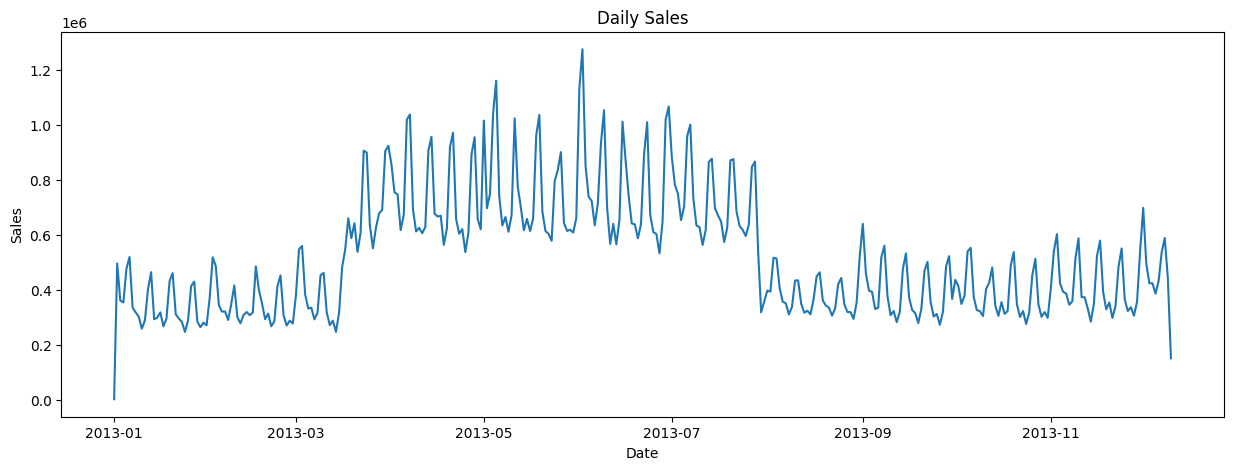

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales["date"], daily_sales["sales"])

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [ ]:
prophet_data = daily_sales.rename(columns={
    "date": "ds",
    "sales": "y"
})

In [ ]:
prophet_data.head()

,ds,y
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [ ]:
prophet_data

,ds,y
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229
...,...,...
339,2013-12-06,432661.755068
340,2013-12-07,537181.319801
341,2013-12-08,588855.895921
342,2013-12-09,442309.314108


In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [ ]:
model.fit(prophet_data)

In [ ]:
future = model.make_future_dataframe(periods=90)

In [ ]:
forecast = model.predict(future)

In [ ]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
429,2014-03-06,513086.835856,416096.907174,602395.060778
430,2014-03-07,571984.504121,483449.223132,659056.243478
431,2014-03-08,773236.746927,680174.866483,859854.751244
432,2014-03-09,816658.903477,727014.768812,901002.277735
433,2014-03-10,640382.061975,552334.440738,736106.276332


In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [ ]:
yearly_seasonality=True

In [ ]:
weekly_seasonality=True

In [ ]:
daily_seasonality=False

In [ ]:
model.fit(prophet_data)

In [ ]:
future = model.make_future_dataframe(periods=90)

In [ ]:
forecast = model.predict(future)

In [ ]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
429,2014-03-06,513086.835856,421778.922217,603188.160332
430,2014-03-07,571984.504121,485882.589194,659900.365566
431,2014-03-08,773236.746927,685534.427703,862689.674222
432,2014-03-09,816658.903477,727164.769764,908876.308498
433,2014-03-10,640382.061975,552991.868295,732945.324815


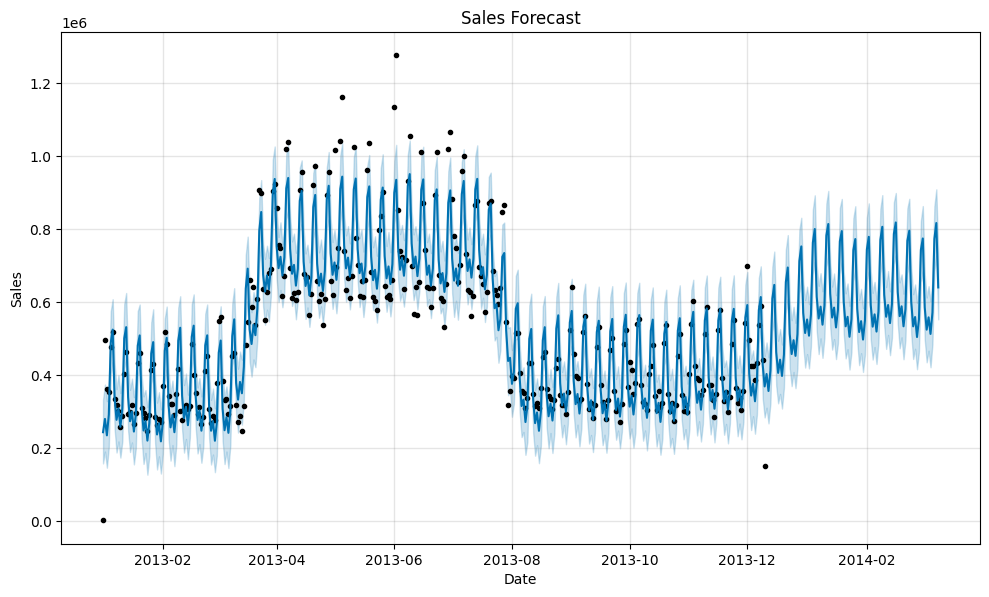

In [ ]:
fig = model.plot(forecast)
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

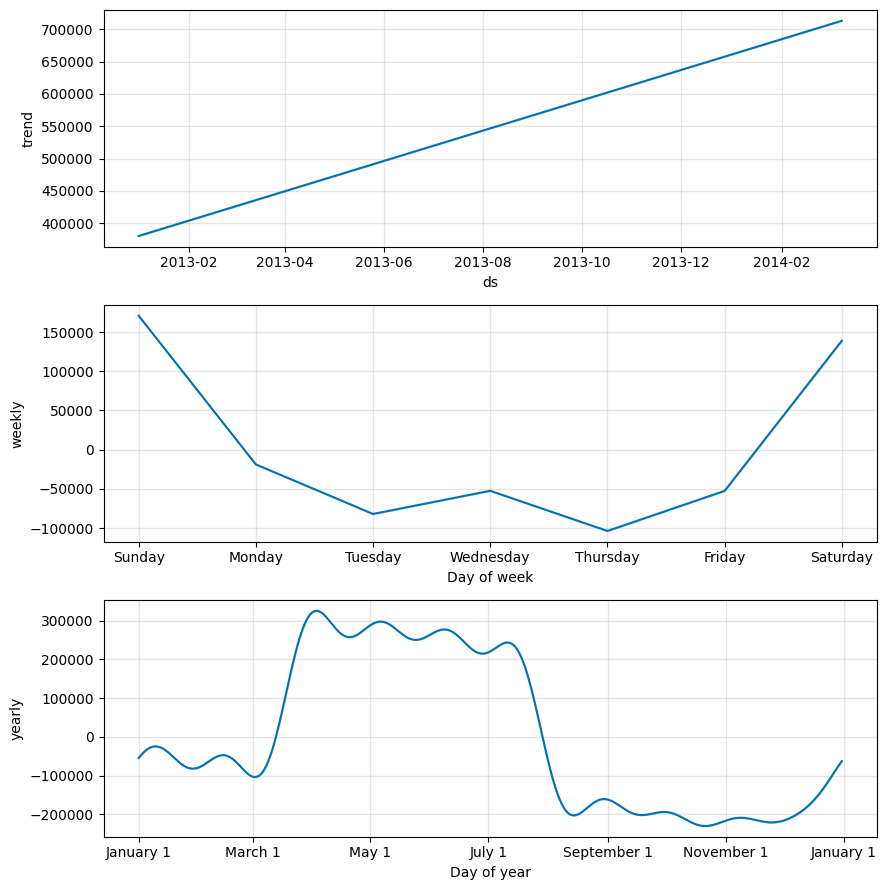

In [ ]:
model.plot_components(forecast)
plt.show()

In [ ]:
# Keep only required columns
holiday_df = holidays[['date', 'description']].copy()

# Rename columns for Prophet
holiday_df.columns = ['ds', 'holiday']

# Convert date column to datetime
holiday_df['ds'] = pd.to_datetime(holiday_df['ds'])

holiday_df.head()

,ds,holiday
0,2012-03-02,Fundacion de Manta
1,2012-04-01,Provincializacion de Cotopaxi
2,2012-04-12,Fundacion de Cuenca
3,2012-04-14,Cantonizacion de Libertad
4,2012-04-21,Cantonizacion de Riobamba


In [ ]:
model_holiday = Prophet(
    holidays=holiday_df,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [ ]:
model_holiday.fit(prophet_data)

In [ ]:
future = model_holiday.make_future_dataframe(periods=90)

forecast_holiday = model_holiday.predict(future)

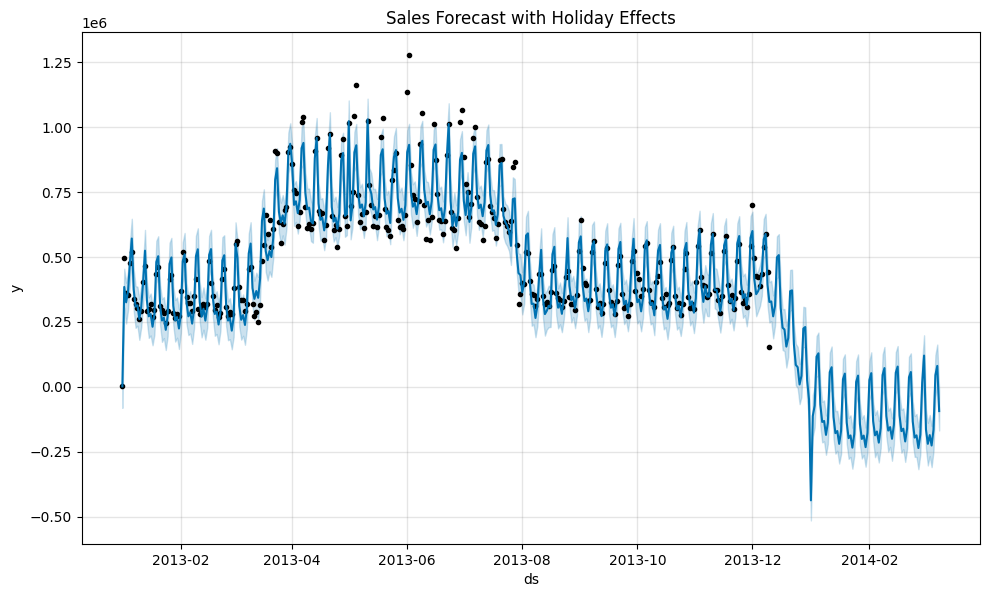

In [ ]:
fig = model_holiday.plot(forecast_holiday)

plt.title("Sales Forecast with Holiday Effects")

plt.show()

In [ ]:
promotion_data = train.groupby("date")["onpromotion"].sum().reset_index()

promotion_data.head()

,date,onpromotion
0,2013-01-01,0.0
1,2013-01-02,0.0
2,2013-01-03,0.0
3,2013-01-04,0.0
4,2013-01-05,0.0


In [ ]:
prophet_data = prophet_data.merge(
    promotion_data,
    left_on="ds",
    right_on="date"
)

prophet_data.drop("date", axis=1, inplace=True)

prophet_data.head()

,ds,y,onpromotion
0,2013-01-01,2511.618999,0.0
1,2013-01-02,496092.417944,0.0
2,2013-01-03,361461.231124,0.0
3,2013-01-04,354459.677093,0.0
4,2013-01-05,477350.121229,0.0


In [ ]:
model_promo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model_promo.add_regressor("onpromotion")

In [ ]:
model_promo.fit(prophet_data)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model_promo.make_future_dataframe(periods=90)

In [ ]:
future["onpromotion"] = prophet_data["onpromotion"].mean()

In [ ]:
forecast_promo = model_promo.predict(future)

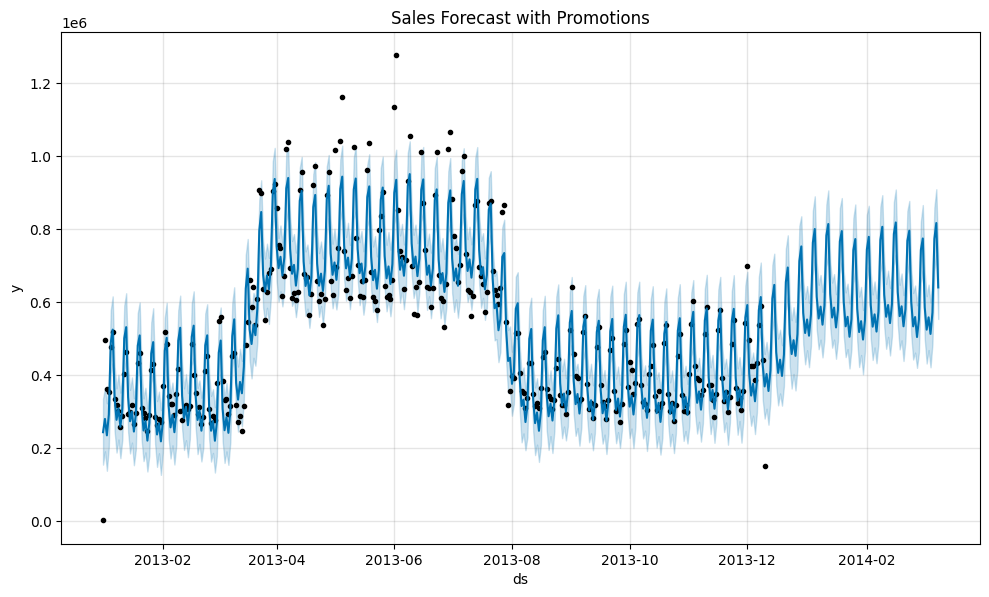

In [ ]:
model_promo.plot(forecast_promo)

plt.title("Sales Forecast with Promotions")

plt.show()

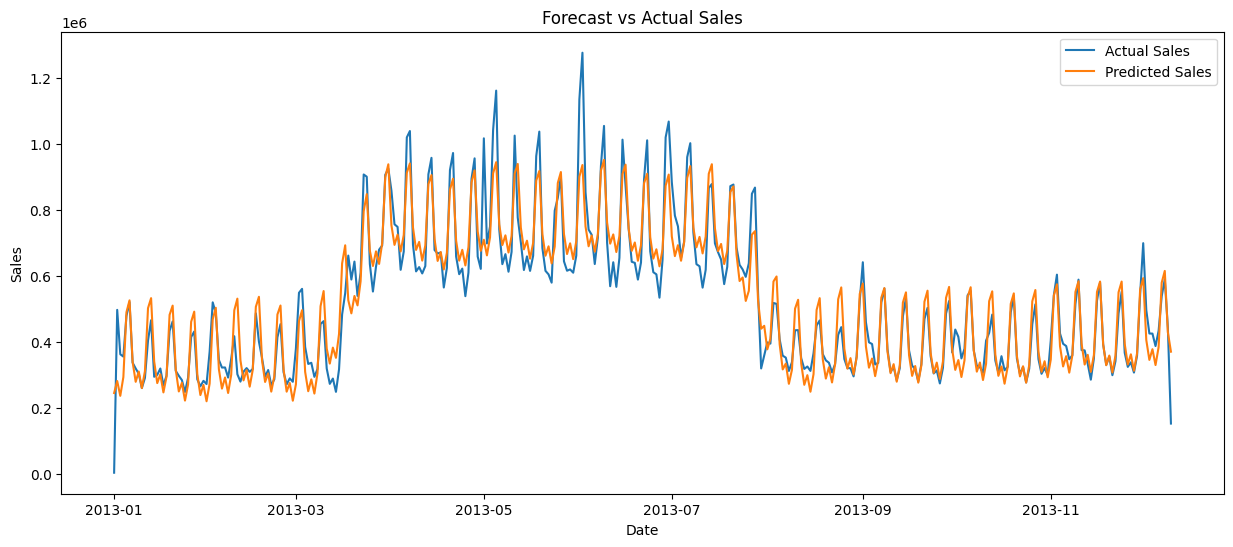

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(prophet_data["ds"], prophet_data["y"], label="Actual Sales")

plt.plot(
    forecast_promo["ds"][:len(prophet_data)],
    forecast_promo["yhat"][:len(prophet_data)],
    label="Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Forecast vs Actual Sales")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
actual = prophet_data["y"]

predicted = forecast_promo["yhat"][:len(actual)]

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE :", mae)

print("RMSE:", rmse)

MAE : 51112.955863201685
RMSE: 69988.67156278787


In [ ]:
forecast_promo.to_csv("sales_forecast.csv", index=False)